<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/Regresi%C3%B3n_lineal_s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ANÁLISIS DE REGRESIÓN LINEAL - PUBLICIDAD Y SEGUIDORES
n=10 | α=0.05 | X=Inversión en Publicidad (miles $) | Y=Nuevos Seguidores (centenas)

--- ESTADÍSTICAS DESCRIPTIVAS Y CORRELACIÓN ---
X: μ=5.50, σ=3.03, rango=[1, 10]
Y: μ=26.70, σ=4.11, rango=[20, 33]

Normalidad (Shapiro-Wilk):
  X: p=0.8924 ✓ Normal
  Y: p=0.9844 ✓ Normal

Correlación: Pearson=0.9686 | Spearman=0.9636
Magnitud: Fuerte | Dirección: Positiva

--- PRUEBA DE CORRELACIÓN ---
H₀: ρ=0 vs H₁: ρ≠0 | t=11.017, t_crit=±2.306, p=0.0000
Decisión: ✓ Rechazar H₀ - Correlación SIGNIFICATIVA

--- MODELO DE REGRESIÓN ---
Ecuación: Ŷ = 19.4667 + 1.3152X
  b₀ (intersección): 19.4667 → Seguidores base sin inversión en publicidad
  b₁ (pendiente): 1.3152 → Por cada mil $ adicional de inversión, +1.3152 centenas de seguidores

Bondad de ajuste:
  R² = 0.9382 (93.8% variabilidad explicada)
  Error estándar (s_y,x) = 1.0843

--- PRUEBAS DE SIGNIFICANCIA (α=0.05) ---
1. Pendiente: H₀: β=0 vs H₁: β≠0
   t=11.017, t_crit=±2.306, p=0.000

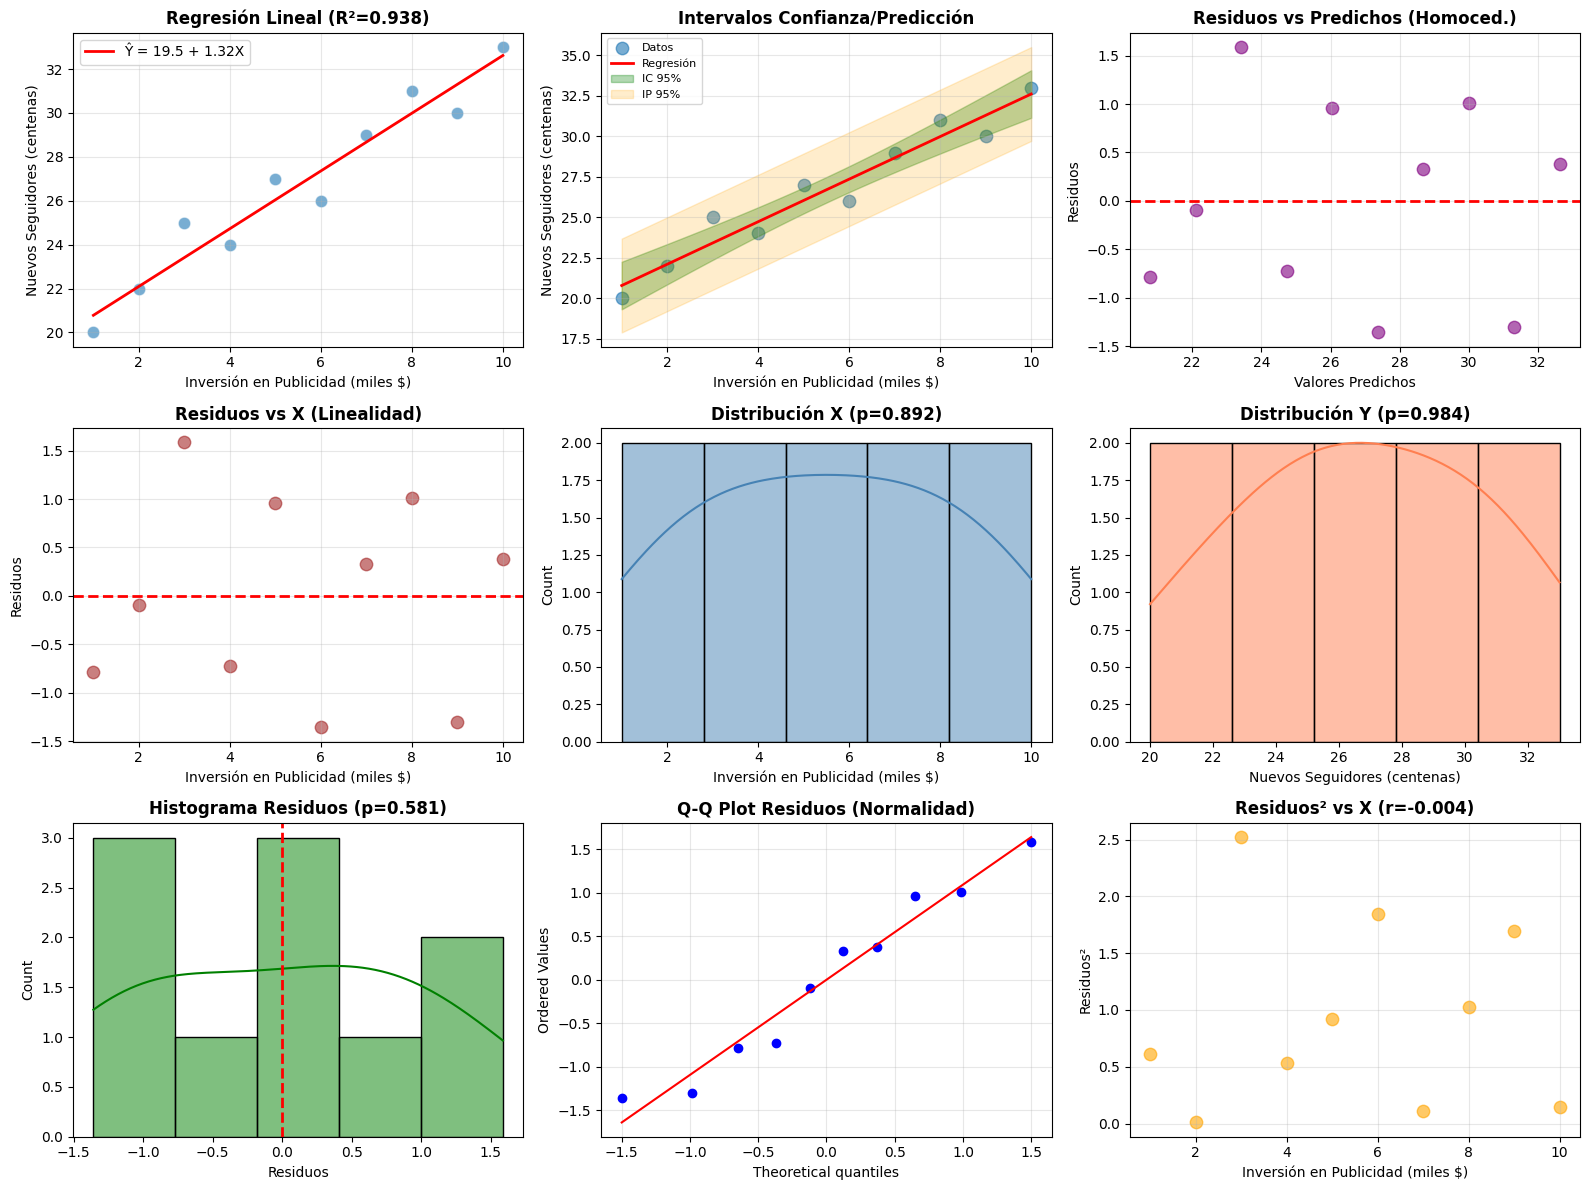


✓ ANÁLISIS COMPLETADO


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist, levene
from scipy import stats
import numpy as np

# --- DATOS ---
data = {
    'Inversión en Publicidad (miles $)': [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10
    ],
    'Nuevos Seguidores (centenas)': [
        20, 22, 25, 24, 27, 26, 29, 31, 30, 33
    ]
}
df = pd.DataFrame(data)

var_x = 'Inversión en Publicidad (miles $)'
var_y = 'Nuevos Seguidores (centenas)'
n, alfa = len(df), 0.05

print("=" * 70)
print("   ANÁLISIS DE REGRESIÓN LINEAL - PUBLICIDAD Y SEGUIDORES")
print("=" * 70)
print(f"n={n} | α={alfa} | X={var_x} | Y={var_y}\n")

# --- ANÁLISIS DESCRIPTIVO ---
mean_x, mean_y = df[var_x].mean(), df[var_y].mean()
std_x, std_y = df[var_x].std(ddof=1), df[var_y].std(ddof=1)
min_x, max_x = df[var_x].min(), df[var_x].max()
min_y, max_y = df[var_y].min(), df[var_y].max()

# Correlaciones y Normalidad
pearson = df[var_x].corr(df[var_y])
spearman = df[var_x].corr(df[var_y], method='spearman')
shapiro_x = shapiro(df[var_x])
shapiro_y = shapiro(df[var_y])

print("--- ESTADÍSTICAS DESCRIPTIVAS Y CORRELACIÓN ---")
print(f"X: μ={mean_x:.2f}, σ={std_x:.2f}, rango=[{min_x}, {max_x}]")
print(f"Y: μ={mean_y:.2f}, σ={std_y:.2f}, rango=[{min_y}, {max_y}]")
print(f"\nNormalidad (Shapiro-Wilk):")
print(f"  X: p={shapiro_x.pvalue:.4f} {'✓ Normal' if shapiro_x.pvalue > alfa else '✗ No normal'}")
print(f"  Y: p={shapiro_y.pvalue:.4f} {'✓ Normal' if shapiro_y.pvalue > alfa else '✗ No normal'}")
print(f"\nCorrelación: Pearson={pearson:.4f} | Spearman={spearman:.4f}")
print(f"Magnitud: {'Fuerte' if abs(pearson) > 0.7 else 'Moderada' if abs(pearson) > 0.4 else 'Débil'} | Dirección: {'Positiva' if pearson > 0 else 'Negativa'}")

# --- PRUEBA DE HIPÓTESIS PARA CORRELACIÓN ---
gl = n - 2
t_corr = pearson * np.sqrt(n - 2) / np.sqrt(1 - pearson**2)
p_corr = t.sf(abs(t_corr), gl) * 2
t_crit_corr = t.ppf(1 - alfa/2, gl)

print(f"\n--- PRUEBA DE CORRELACIÓN ---")
print(f"H₀: ρ=0 vs H₁: ρ≠0 | t={t_corr:.3f}, t_crit=±{t_crit_corr:.3f}, p={p_corr:.4f}")
print(f"Decisión: {'✓ Rechazar H₀ - Correlación SIGNIFICATIVA' if p_corr < alfa else '✗ No rechazar H₀'}")

# --- REGRESIÓN Y PRUEBAS ---
b1 = pearson * (std_y / std_x)
b0 = mean_y - b1 * mean_x
df['y_pred'] = b0 + b1 * df[var_x]
df['residuos'] = df[var_y] - df['y_pred']

# Errores y pruebas
SSE = ((df[var_y] - df['y_pred']) ** 2).sum()
SS_Total = ((df[var_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE
s_yx = np.sqrt(SSE / (n - 2))
suma_desv_x = ((df[var_x] - mean_x) ** 2).sum()
s_b = s_yx / np.sqrt(suma_desv_x)
r2 = 1 - (SSE / SS_Total)

# Estadísticos t y F
t_calc = b1 / s_b
p_val_t = t.sf(abs(t_calc), gl) * 2  # dos colas
t_crit_pend = t.ppf(1 - alfa/2, gl)
F_calc = (SSR / 1) / (SSE / gl)
p_val_f = f_dist.sf(F_calc, 1, gl)

print(f"\n--- MODELO DE REGRESIÓN ---")
print(f"Ecuación: Ŷ = {b0:.4f} + {b1:.4f}X")
print(f"  b₀ (intersección): {b0:.4f} → Seguidores base sin inversión en publicidad")
print(f"  b₁ (pendiente): {b1:.4f} → Por cada mil $ adicional de inversión, +{b1:.4f} centenas de seguidores")
print(f"\nBondad de ajuste:")
print(f"  R² = {r2:.4f} ({r2*100:.1f}% variabilidad explicada)")
print(f"  Error estándar (s_y,x) = {s_yx:.4f}")

print(f"\n--- PRUEBAS DE SIGNIFICANCIA (α={alfa}) ---")
print(f"1. Pendiente: H₀: β=0 vs H₁: β≠0")
print(f"   t={t_calc:.3f}, t_crit=±{t_crit_pend:.3f}, p={p_val_t:.4f}")
print(f"   → {'✓ Pendiente SIGNIFICATIVA' if p_val_t < alfa else '✗ Pendiente NO significativa'}")
print(f"\n2. Modelo (ANOVA): H₀: modelo no significativo vs H₁: modelo significativo")
print(f"   F={F_calc:.3f}, p={p_val_f:.6f}")
print(f"   → {'✓ Modelo SIGNIFICATIVO' if p_val_f < alfa else '✗ Modelo NO significativo'}")

# --- TABLA ANOVA ---
print(f"\n--- TABLA ANOVA ---")
print(f"{'Fuente':<12} {'SS':<12} {'gl':<6} {'MS':<12} {'F':<10} {'p-valor':<10}")
print("-" * 62)
print(f"{'Regresión':<12} {SSR:<12.4f} {1:<6} {SSR:<12.4f} {F_calc:<10.3f} {p_val_f:<10.6f}")
print(f"{'Error':<12} {SSE:<12.4f} {gl:<6} {SSE/gl:<12.4f}")
print(f"{'Total':<12} {SS_Total:<12.4f} {n-1:<6}")

# --- SUPUESTOS DEL MODELO ---
print(f"\n{'='*70}")
print("--- VALIDACIÓN DE SUPUESTOS DEL MODELO ---")
print(f"{'='*70}")

# 1. LINEALIDAD (visual - revisar gráfico)
print(f"\n1. LINEALIDAD:")
print(f"   • Correlación alta sugiere relación lineal: r={pearson:.4f}")
print(f"   • Revisar diagrama de dispersión para confirmar")
print(f"   → {'✓ Supuesto plausible' if abs(pearson) > 0.5 else '⚠ Revisar gráfico - correlación débil'}")

# 2. INDEPENDENCIA (no se puede probar con estos datos transversales)
print(f"\n2. INDEPENDENCIA:")
print(f"   • No hay orden temporal en los datos")
print(f"   • Asumimos observaciones independientes entre puntos de tiempo/campañas")
print(f"   → ✓ Supuesto asumido (datos transversales)")

# 3. NORMALIDAD DE RESIDUOS
shapiro_res = shapiro(df['residuos'])
print(f"\n3. NORMALIDAD DE RESIDUOS:")
print(f"   • Shapiro-Wilk: W={shapiro_res.statistic:.4f}, p={shapiro_res.pvalue:.4f}")
print(f"   • Media residuos: {df['residuos'].mean():.4f} (debe ≈ 0)")
print(f"   → {'✓ Residuos normales' if shapiro_res.pvalue > alfa else '⚠ Residuos NO normales'}")

# 4. HOMOCEDASTICIDAD (varianza constante)
df['res_std'] = df['residuos'] / s_yx
# Prueba de Breusch-Pagan simplificada: correlación entre residuos² y X
residuos_cuadrados = df['residuos'] ** 2
corr_hetero = df[var_x].corr(residuos_cuadrados)
# Dividir en dos grupos y aplicar Levene
mediana_x = df[var_x].median()
grupo1 = df[df[var_x] <= mediana_x]['residuos'].abs()
grupo2 = df[df[var_x] > mediana_x]['residuos'].abs()
levene_stat, levene_p = levene(grupo1, grupo2)

print(f"\n4. HOMOCEDASTICIDAD (varianza constante):")
print(f"   • Test de Levene: W={levene_stat:.4f}, p={levene_p:.4f}")
print(f"   • Correlación |residuos| vs X: {corr_hetero:.4f}")
print(f"   • Revisar gráfico 'Residuos vs Predichos' (debe ser aleatorio)")
if levene_p > alfa and abs(corr_hetero) < 0.3:
    print(f"   → ✓ Homocedasticidad cumplida")
elif levene_p <= alfa:
    print(f"   → ⚠ Posible heterocedasticidad detectada")
else:
    print(f"   → ⚠ Revisar gráficamente - correlación moderada")

# 5. OUTLIERS
outliers = df[np.abs(df['res_std']) > 2.5]
print(f"\n5. VALORES ATÍPICOS (OUTLIERS):")
print(f"   • Outliers (|res_std| > 2.5): {len(outliers)}/{n} ({len(outliers)/n*100:.1f}%)")
if len(outliers) > 0:
    for idx, row in outliers.iterrows():
        print(f"     • Inversión {row[var_x]:.0f} miles $: res_std={row['res_std']:.2f}")
print(f"   → {'✓ Sin outliers significativos' if len(outliers) == 0 else '⚠ Revisar outliers identificados'}")

# --- RESUMEN DE SUPUESTOS ---
supuestos_ok = (
    abs(pearson) > 0.5 and
    shapiro_res.pvalue > alfa and
    (levene_p > alfa and abs(corr_hetero) < 0.3) and
    len(outliers) <= n * 0.15
)

print(f"\n{'='*70}")
print(f"RESUMEN DE SUPUESTOS: {'✓ TODOS CUMPLIDOS' if supuestos_ok else '⚠ REVISAR SUPUESTOS'}")
print(f"{'='*70}")

# --- INTERVALOS (ejemplos) ---
t_crit = t.ppf(1 - alfa/2, gl)
x_ejemplos = [2, 5, 8, 10]

print(f"\n--- INTERVALOS DE CONFIANZA Y PREDICCIÓN (95%) ---")
print(f"{'X':<8} {'Ŷ':<10} {'IC Media':<25} {'IP Individual':<25}")
print("-" * 68)

for x_val in x_ejemplos:
    y_pred = b0 + b1 * x_val

    # IC para la media
    error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    margen_conf = t_crit * s_yx * error_conf
    ic_inf, ic_sup = y_pred - margen_conf, y_pred + margen_conf

    # IP individual
    error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    margen_pred = t_crit * s_yx * error_pred
    ip_inf, ip_sup = y_pred - margen_pred, y_pred + margen_pred

    print(f"{x_val:<8} {y_pred:<10.2f} [{ic_inf:.1f}, {ic_sup:.1f}]{'':>10} [{ip_inf:.1f}, {ip_sup:.1f}]")

# --- EVALUACIÓN DE TRANSFORMACIÓN ---
print(f"\n--- ¿NECESITA TRANSFORMACIÓN DE DATOS? ---")
necesita = False
razones = []

if shapiro_x.pvalue <= alfa or shapiro_y.pvalue <= alfa:
    razones.append("Variables originales no normales")
    necesita = True
if shapiro_res.pvalue <= alfa:
    razones.append("Residuos no normales")
    necesita = True
if levene_p <= alfa or abs(corr_hetero) >= 0.3:
    razones.append("Posible heterocedasticidad")
    necesita = True
if abs(pearson) < 0.5:
    razones.append(f"Correlación débil (r={pearson:.3f})")
    necesita = True
if len(outliers) > n * 0.15:
    razones.append(f"Exceso de outliers ({len(outliers)})")
    necesita = True

if necesita:
    print("⚠ CONSIDERAR TRANSFORMACIÓN:")
    for r in razones:
        print(f"  • {r}")
    print("\n  Transformaciones sugeridas:")
    print("    - log(Y): reduce asimetría positiva, estabiliza varianza")
    print("    - √Y: para datos de conteo con varianza proporcional a media")
    print("    - 1/Y: para relaciones no lineales decrecientes")
    print("    - Box-Cox: encuentra transformación óptima automáticamente")
else:
    print("✓ NO NECESARIA - Todos los supuestos cumplidos adecuadamente")

# --- RESUMEN EJECUTIVO ---
print(f"\n{'='*70}")
print("                        RESUMEN EJECUTIVO")
print(f"{'='*70}")
print(f"""
📊 MODELO: Ŷ = {b0:.2f} + {b1:.3f}X
   Interpretación: Por cada mil dólares adicionales de inversión en publicidad → +{b1:.3f} centenas de nuevos seguidores

📈 BONDAD DE AJUSTE:
   • R² = {r2:.3f} ({r2*100:.1f}% variabilidad explicada)
   • Correlación {'fuerte' if abs(pearson) > 0.7 else 'moderada' if abs(pearson) > 0.4 else 'débil'}: r = {pearson:.3f}
   • Error típico de predicción: ±{s_yx:.2f} centenas de seguidores

✅ SIGNIFICANCIA ESTADÍSTICA:
   • Correlación: {'✓ Significativa' if p_corr < alfa else '✗ No significativa'} (p={p_corr:.4f})
   • Pendiente: {'✓ Significativa' if p_val_t < alfa else '✗ No significativa'} (p={p_val_t:.4f})
   • Modelo: {'✓ Significativo' if p_val_f < alfa else '✗ No significativo'} (p={p_val_f:.6f})

🔍 VALIDACIÓN DE SUPUESTOS:
   • Linealidad: {'✓' if abs(pearson) > 0.5 else '⚠'}
   • Independencia: ✓ (asumido)
   • Normalidad residuos: {'✓' if shapiro_res.pvalue > alfa else '⚠'} (p={shapiro_res.pvalue:.3f})
   • Homocedasticidad: {'✓' if levene_p > alfa and abs(corr_hetero) < 0.3 else '⚠'} (Levene p={levene_p:.3f})
   • Outliers: {len(outliers)}/{n} → {'✓ Aceptable' if len(outliers) <= n*0.15 else '⚠ Revisar'}

💡 CONCLUSIÓN:""")

if p_val_t < alfa and p_val_f < alfa and supuestos_ok:
    print(f"""   ✓✓ EL MODELO ES VÁLIDO Y CONFIABLE PARA PREDICCIONES

   El modelo cumple todos los supuestos y las pruebas estadísticas confirman
   que la inversión en publicidad es un predictor significativo de los nuevos
   seguidores. Se recomienda IMPLEMENTAR este modelo para:
   • Planificación de la inversión en marketing digital
   • Establecimiento de metas de crecimiento de seguidores
   • Predicción de resultados de campañas de publicidad""")
elif p_val_t < alfa and p_val_f < alfa:
    print(f"""   ⚠ MODELO SIGNIFICATIVO pero con SUPUESTOS COMPROMETIDOS

   Aunque las pruebas son significativas, algunos supuestos no se cumplen
   completamente. Usar con PRECAUCIÓN y considerar:
   • Transformación de datos (ver recomendaciones arriba)
   • Recolectar más observaciones o datos adicionales
   • Investigar outliers identificados""")
else:
    print(f"""   ✗ MODELO CON LIMITACIONES SIGNIFICATIVAS

   El modelo NO es estadísticamente confiable. Se recomienda:
   • Recolectar más datos o mejorar calidad de datos
   • Considerar otras variables explicativas (ej. contenido, horario)
   • Explorar modelos alternativos (no lineal, multivariado)""")

print("\n" + "=" * 70)

# --- GRÁFICOS ---
fig = plt.figure(figsize=(16, 12))

# 1. Dispersión con regresión
ax1 = plt.subplot(3, 3, 1)
sns.scatterplot(x=var_x, y=var_y, data=df, s=80, alpha=0.6)
x_line = np.linspace(df[var_x].min(), df[var_x].max(), 100)
y_line = b0 + b1 * x_line
plt.plot(x_line, y_line, 'r-', lw=2, label=f'Ŷ = {b0:.1f} + {b1:.2f}X')
plt.title(f'Regresión Lineal (R²={r2:.3f})', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.legend()
plt.grid(alpha=0.3)

# 2. Regresión con intervalos
ax2 = plt.subplot(3, 3, 2)
plt.scatter(df[var_x], df[var_y], s=80, alpha=0.6, label='Datos')
plt.plot(x_line, y_line, 'r-', lw=2, label='Regresión')

# Calcular bandas
ic_lower, ic_upper = [], []
ip_lower, ip_upper = [], []
for x_val in x_line:
    y_p = b0 + b1 * x_val
    e_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    e_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desv_x))
    ic_lower.append(y_p - t_crit * s_yx * e_conf)
    ic_upper.append(y_p + t_crit * s_yx * e_conf)
    ip_lower.append(y_p - margen_pred)
    ip_upper.append(y_p + margen_pred)

plt.fill_between(x_line, ic_lower, ic_upper, alpha=0.3, color='green', label='IC 95%')
plt.fill_between(x_line, ip_lower, ip_upper, alpha=0.2, color='orange', label='IP 95%')
plt.title('Intervalos Confianza/Predicción', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 3. Residuos vs Predichos (HOMOCEDASTICIDAD)
ax3 = plt.subplot(3, 3, 3)
plt.scatter(df['y_pred'], df['residuos'], s=80, alpha=0.6, color='purple')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title('Residuos vs Predichos (Homoced.)', fontweight='bold')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.grid(alpha=0.3)

# 4. Residuos vs X
ax4 = plt.subplot(3, 3, 4)
plt.scatter(df[var_x], df['residuos'], s=80, alpha=0.6, color='brown')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title('Residuos vs X (Linealidad)', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel('Residuos')
plt.grid(alpha=0.3)

# 5. Histograma X
ax5 = plt.subplot(3, 3, 5)
sns.histplot(df[var_x], kde=True, color='steelblue')
plt.title(f'Distribución X (p={shapiro_x.pvalue:.3f})', fontweight='bold')
plt.xlabel(var_x)

# 6. Histograma Y
ax6 = plt.subplot(3, 3, 6)
sns.histplot(df[var_y], kde=True, color='coral')
plt.title(f'Distribución Y (p={shapiro_y.pvalue:.3f})', fontweight='bold')
plt.xlabel(var_y)

# 7. Histograma Residuos
ax7 = plt.subplot(3, 3, 7)
sns.histplot(df['residuos'], kde=True, color='green')
plt.axvline(0, color='r', linestyle='--', lw=2)
plt.title(f'Histograma Residuos (p={shapiro_res.pvalue:.3f})', fontweight='bold')
plt.xlabel('Residuos')

# 8. Q-Q Plot Residuos
ax8 = plt.subplot(3, 3, 8)
stats.probplot(df['residuos'], dist="norm", plot=ax8)
plt.title('Q-Q Plot Residuos (Normalidad)', fontweight='bold')
plt.grid(alpha=0.3)

# 9. Gráfico de dispersión de residuos² vs X (Heterocedasticidad visual)
ax9 = plt.subplot(3, 3, 9)
plt.scatter(df[var_x], residuos_cuadrados, s=80, alpha=0.6, color='orange')
plt.title(f'Residuos² vs X (r={corr_hetero:.3f})', fontweight='bold')
plt.xlabel(var_x)
plt.ylabel('Residuos²')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ ANÁLISIS COMPLETADO")

Objetivo a saber del problema: ¿Si invierto más dinero en publicidad, aumentan los seguidores?

Entonces:

X = dinero invertido
Y = seguidores ganados

Y la regresión lineal busca encontrar una línea que relacione esas dos variables.

*  La correlación es r= 0.9686 o sea la relación es muy fuerte y positiva. Cuando aumentan la publicidad también aumenta los seguidores.
*  Y^=19.47+1.315X (19.47 valor inicial incluso sin invertir publicidad se esperan aproximadamente 19.47 centenas de seguidores). (1.315 por cada mil dólares adicionales invertidos, aumentan aproximadamente 1.315 centenas de seguidores, eso es la pendiente).
*  R2=0.9382
El modelo explica el 93.8% del comportamiento de los seguidores. O sea se ajusta muy bien.
*  H₀:No existe relación entre publicidad y seguidores
H₁: Sí existe relación
p=0.0000 0.0000<0.05 por eso se rechaza H0 O sea si existe relación significativa entre publicidad y seguidores


##Gráficas
*  Regresión:

Relación positiva.

*  Residuos:

Aleatorios → modelo válido.

*  Histogramas/Q-Q:

Normalidad

+  Residuos²:

Homocedasticidad

Las gráficas muestran que los supuestos del modelo se cumplen adecuadamente, ya que existe linealidad, normalidad y homocedasticidad, por lo cual el modelo de regresión es válido y confiable para predicción.
